In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("brfss_clean_2020_2024.csv")

race_map = {
    1: "NH-White", 2: "NH-Black", 3: "AIAN",
    4: "Asian", 5: "NHOPI", 6: "Other/Multiracial",
    7: "Hispanic"
}
age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}
sex_map = {1: "Male", 2: "Female"}
education_map = {
    1: "Did not graduate high school",
    2: "Graduated high school",
    3: "Attended college or technical school",
    4: "Graduated college or technical school"
}
income_map = {
    1: "<15k", 2: "15k-25k", 3: "25k-35k",
    4: "35k-50k", 5: "50k-100k", 6: "100k-200k", 7: "200k+"
}

df["race_group"]   = df["_RACEPRV"].map(race_map)
df["age_group"]    = df["_AGEG5YR"].map(age_map)
df["sex"]          = df["_SEX"].map(sex_map)
df["education"]    = df["_EDUCAG"].map(education_map)
df["income_group"] = df["_INCOMG1"].map(income_map)

print("Shape:", df.shape)
print("Years:", sorted(df["year"].unique()))

Shape: (1622499, 19)
Years: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [2]:
# Trend by race
trend_race = (
    df.groupby(["year", "race_group"])
    .apply(lambda g: np.average(g["obese"], weights=g["_LLCPWT_adjusted"]))
    .reset_index()
)
trend_race.columns = ["year", "race_group", "obesity_rate"]

# Trend by sex
trend_sex = (
    df.groupby(["year", "sex"])
    .apply(lambda g: np.average(g["obese"], weights=g["_LLCPWT_adjusted"]))
    .reset_index()
)
trend_sex.columns = ["year", "sex", "obesity_rate"]

# Trend by education
trend_edu = (
    df.groupby(["year", "education"])
    .apply(lambda g: np.average(g["obese"], weights=g["_LLCPWT_adjusted"]))
    .reset_index()
)
trend_edu.columns = ["year", "education", "obesity_rate"]

# Trend by income (2021-2024 only since 2020 income is NaN)
trend_income = (
    df.dropna(subset=["income_group"])
    .groupby(["year", "income_group"])
    .apply(lambda g: np.average(g["obese"], weights=g["_LLCPWT_adjusted"]))
    .reset_index()
)
trend_income.columns = ["year", "income_group", "obesity_rate"]

# Trend by age
trend_age = (
    df.groupby(["year", "age_group"])
    .apply(lambda g: np.average(g["obese"], weights=g["_LLCPWT_adjusted"]))
    .reset_index()
)
trend_age.columns = ["year", "age_group", "obesity_rate"]

print("Race trend shape:", trend_race.shape)
print("Sex trend shape:", trend_sex.shape)
print("Education trend shape:", trend_edu.shape)
print("Income trend shape:", trend_income.shape)
print("Age trend shape:", trend_age.shape)

print("\nRace trend sample:")
print(trend_race[trend_race["year"]==2024].sort_values("obesity_rate", ascending=False).to_string(index=False))

Race trend shape: (35, 3)
Sex trend shape: (10, 3)
Education trend shape: (20, 3)
Income trend shape: (28, 3)
Age trend shape: (65, 3)

Race trend sample:
 year        race_group  obesity_rate
 2024          NH-Black      0.428991
 2024              AIAN      0.417234
 2024             NHOPI      0.394633
 2024          Hispanic      0.365718
 2024 Other/Multiracial      0.337364
 2024          NH-White      0.334416
 2024             Asian      0.141428


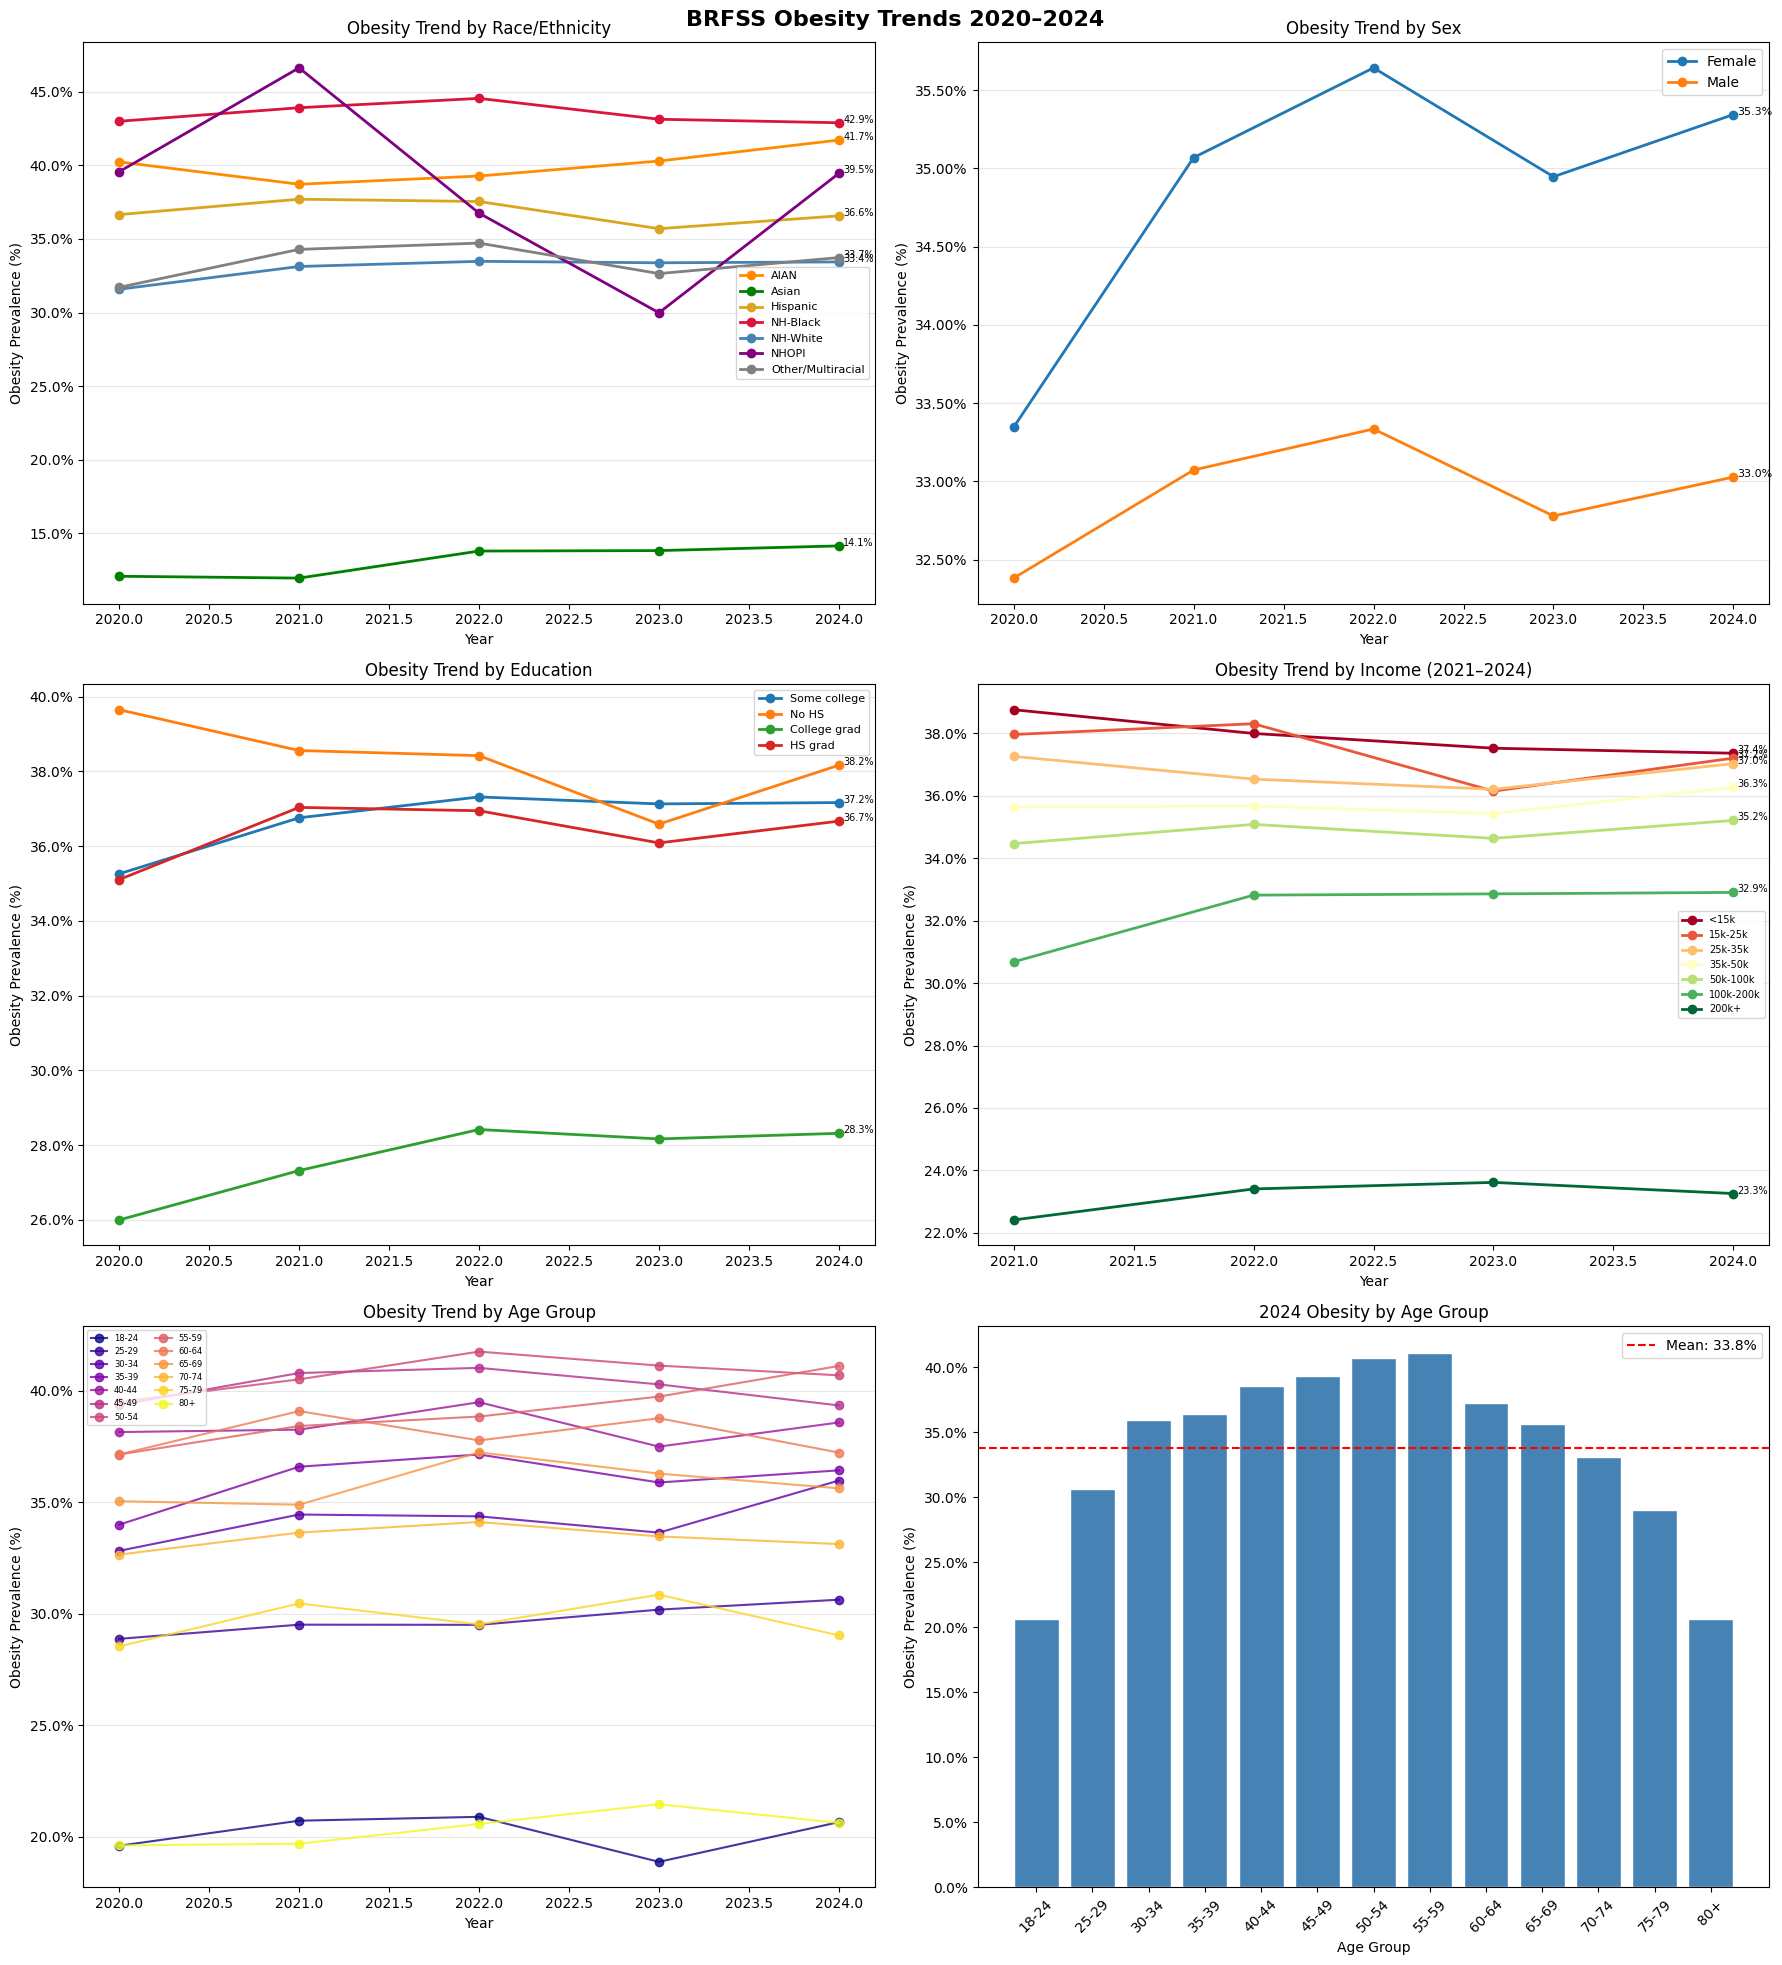

saved brfss_trend_plots.png


In [3]:
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle("BRFSS Obesity Trends 2020–2024", fontsize=16, fontweight="bold")

# Plot 1 — Trend by race
ax = axes[0, 0]
race_colors = {
    "NH-White": "steelblue", "NH-Black": "crimson",
    "AIAN": "darkorange", "Asian": "green",
    "NHOPI": "purple", "Other/Multiracial": "gray",
    "Hispanic": "goldenrod"
}
for race in trend_race["race_group"].unique():
    d = trend_race[trend_race["race_group"] == race]
    ax.plot(d["year"], d["obesity_rate"] * 100, marker="o",
            label=race, color=race_colors.get(race, "black"), linewidth=2)
    ax.annotate(f'{d["obesity_rate"].iloc[-1]*100:.1f}%',
                (d["year"].iloc[-1], d["obesity_rate"].iloc[-1] * 100),
                fontsize=7, xytext=(3, 0), textcoords="offset points")
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Obesity Trend by Race/Ethnicity")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Plot 2 — Trend by sex
ax = axes[0, 1]
for sex in trend_sex["sex"].unique():
    d = trend_sex[trend_sex["sex"] == sex]
    ax.plot(d["year"], d["obesity_rate"] * 100, marker="o",
            label=sex, linewidth=2)
    ax.annotate(f'{d["obesity_rate"].iloc[-1]*100:.1f}%',
                (d["year"].iloc[-1], d["obesity_rate"].iloc[-1] * 100),
                fontsize=8, xytext=(3, 0), textcoords="offset points")
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Obesity Trend by Sex")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Plot 3 — Trend by education
ax = axes[1, 0]
edu_short = {
    "Did not graduate high school": "No HS",
    "Graduated high school": "HS grad",
    "Attended college or technical school": "Some college",
    "Graduated college or technical school": "College grad"
}
for edu in trend_edu["education"].unique():
    d = trend_edu[trend_edu["education"] == edu]
    ax.plot(d["year"], d["obesity_rate"] * 100, marker="o",
            label=edu_short.get(edu, edu), linewidth=2)
    ax.annotate(f'{d["obesity_rate"].iloc[-1]*100:.1f}%',
                (d["year"].iloc[-1], d["obesity_rate"].iloc[-1] * 100),
                fontsize=7, xytext=(3, 0), textcoords="offset points")
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Obesity Trend by Education")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Plot 4 — Trend by income (2021-2024)
ax = axes[1, 1]
income_order = ["<15k", "15k-25k", "25k-35k", "35k-50k", "50k-100k", "100k-200k", "200k+"]
income_colors = plt.cm.RdYlGn(np.linspace(0, 1, len(income_order)))
for i, inc in enumerate(income_order):
    d = trend_income[trend_income["income_group"] == inc]
    ax.plot(d["year"], d["obesity_rate"] * 100, marker="o",
            label=inc, color=income_colors[i], linewidth=2)
    ax.annotate(f'{d["obesity_rate"].iloc[-1]*100:.1f}%',
                (d["year"].iloc[-1], d["obesity_rate"].iloc[-1] * 100),
                fontsize=7, xytext=(3, 0), textcoords="offset points")
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Obesity Trend by Income (2021–2024)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=7)
ax.grid(axis="y", alpha=0.3)

# Plot 5 — Trend by age
ax = axes[2, 0]
age_order = ["18-24", "25-29", "30-34", "35-39", "40-44", "45-49",
             "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"]
colors_age = plt.cm.plasma(np.linspace(0, 1, len(age_order)))
for i, age in enumerate(age_order):
    d = trend_age[trend_age["age_group"] == age]
    ax.plot(d["year"], d["obesity_rate"] * 100, marker="o",
            color=colors_age[i], linewidth=1.5, alpha=0.8, label=age)
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("Obesity Trend by Age Group")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(fontsize=6, ncol=2)
ax.grid(axis="y", alpha=0.3)

# Plot 6 — 2024 snapshot by age (bar chart)
ax = axes[2, 1]
age_2024 = trend_age[trend_age["year"] == 2024].set_index("age_group")
age_2024 = age_2024.loc[age_order]
bars = ax.bar(age_order, age_2024["obesity_rate"] * 100, color="steelblue", edgecolor="white")
ax.axhline(age_2024["obesity_rate"].mean() * 100, color="red",
           linestyle="--", linewidth=1.5,
           label=f'Mean: {age_2024["obesity_rate"].mean()*100:.1f}%')
ax.set_xlabel("Age Group")
ax.set_ylabel("Obesity Prevalence (%)")
ax.set_title("2024 Obesity by Age Group")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig("brfss_trend_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved brfss_trend_plots.png")

In [4]:
# Save all trend files
trend_race.to_csv("brfss_trend_by_race.csv", index=False)
trend_sex.to_csv("brfss_trend_by_sex.csv", index=False)
trend_edu.to_csv("brfss_trend_by_education.csv", index=False)
trend_income.to_csv("brfss_trend_by_income.csv", index=False)
trend_age.to_csv("brfss_trend_by_age.csv", index=False)

print("Saved:")
print("  brfss_trend_by_race.csv")
print("  brfss_trend_by_sex.csv")
print("  brfss_trend_by_education.csv")
print("  brfss_trend_by_income.csv")
print("  brfss_trend_by_age.csv")

Saved:
  brfss_trend_by_race.csv
  brfss_trend_by_sex.csv
  brfss_trend_by_education.csv
  brfss_trend_by_income.csv
  brfss_trend_by_age.csv


## Obesity Trends 2020–2024 — Summary

### Data
Weighted obesity prevalence trends computed from 1,622,499 BRFSS respondents
across 2020–2024 using `_LLCPWT_adjusted`. Income trends use 2021–2024 only
due to incompatible 2020 income bin structure.

### Key Findings

**Racial disparities are large and persistent.**
NH-Black (42.9%) and AIAN (41.7%) have the highest obesity rates in 2024,
roughly three times higher than Asian (14.1%). These gaps are consistent
across all five years with no evidence of narrowing.

**Income gradient is strong and consistent.**
Obesity decreases monotonically with income — from 37-38% at <15k to
23.3% at 200k+, a 15 percentage point gap. The gradient is stable across
2021–2024 with no meaningful convergence.

**Education gradient is clear but smaller.**
College graduates have obesity rates ~10 percentage points lower than
those who did not graduate high school (28.3% vs 38.2% in 2024).

**Age follows an inverted U shape.**
Obesity peaks at ages 50–54 (~41%) and declines sharply after 70,
dropping to ~20% at 80+. The youngest group (18–24) is also low at ~20%.
This pattern is consistent across all years.

**Sex differences are modest.**
Females are consistently slightly higher than males (~35% vs ~33%).
Both show the same year-to-year pattern.

**National trend is stable post-2020.**
A step up from 2020 (32.9%) to 2021 (34.0%) is partly attributable
to the 2020 income exclusion affecting weight calibration. From 2021
onward the national rate is stable between 33.8% and 34.5%.